In [11]:
import os
from src.datasets import SIMln, SIMG, SIMc, SIM, Tuebingen, skewANsLSs, ANs, LSs, AN, LS, MNU, Cha, Multi, Net
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import time
from scipy import stats
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.model_selection import KFold

In [56]:
def calc_acc(results_dict, strat="IT"):
    results = results_dict
    n = len(results.keys())
    n_correct = 0
    if strat == "IT":
        for j in results.keys():
            n_correct += results[j]["correct_IT"]    
    elif strat == "LL":
        for j in results.keys():
            n_correct += results[j]["correct_LL"]
    elif strat == "LL_KDE":
        for j in results.keys():
            n_correct += results[j]["correct_LL_KDE"]
    else:
        raise ValueError("strat needs to be LL or IT or LL_KDE")
    return n_correct/n

def calc_AUDRC(results_dict, strat="IT"):
    correct_key = f"correct_{strat}"

    if strat == "IT":
        score_key = "indep_score" 
    elif strat == "LL":
        score_key = "lik_score" 
    else:
        score_key = "lik_score_kde" 
    
    sorted_items = sorted(
        results_dict.items(),
        key=lambda item: abs(item[1][score_key]), # item[1] is the value of the (key, value pair) 
        reverse=True
    )

    correct_predictions = [item[1][correct_key] for item in sorted_items]
    cumulative_correct = np.cumsum(correct_predictions)
    decision_recall = cumulative_correct / (np.arange(1, len(correct_predictions) + 1))

    auc = decision_recall.mean()
    return auc

In [43]:
import pandas as pd

def load_tuebingen_weights():
    weights_df = pd.read_csv("experiments/results/Tuebingen_weights.csv", sep=",")  # or sep="," if it's CSV
    weights = dict(zip(weights_df["PairID"], weights_df["Weight"]))
    return weights

def calc_acc_weighted(results_dict, strat, weights):
    weighted_correct = 0
    for j in results_dict:
        if strat == "IT":
            weighted_correct += weights[j] * int(results_dict[j]["correct_IT"])
        elif strat == "LL":
            weighted_correct += weights[j] * int(results_dict[j]["correct_LL"])
        else:
            weighted_correct += weights[j] * int(results_dict[j]["correct_LL_KDE"])
    return weighted_correct / np.sum(np.array([j for j in weights.values()]))

def calc_AUDRC_weighted(results_dict, strat, weights):
    if strat == "IT":
        result_list = [
            (abs(results_dict[j]["indep_score"]), int(results_dict[j]["correct_IT"]), weights[j])
            for j in results_dict
        ]
    elif strat == "LL":
        result_list = [
            (abs(results_dict[j]["lik_score"]), int(results_dict[j]["correct_LL"]), weights[j])
            for j in results_dict
        ]
    else:
        result_list = [
            (abs(results_dict[j]["lik_score_kde"]), int(results_dict[j]["correct_LL_KDE"]), weights[j])
            for j in results_dict
        ]
    # Sort by abs score
    result_list.sort(reverse=True, key=lambda x: x[0])

    weights_sorted = np.array([r[2] for r in result_list])
    correct_sorted = np.array([r[1] for r in result_list])
    correct_weighted = weights_sorted * correct_sorted

    cum_cw = np.cumsum(correct_weighted)
    cum_w = np.cumsum(weights_sorted)

    cp = cum_cw/cum_w

    audrc = np.sum(weights_sorted * cp)/np.sum(weights_sorted)
    return(audrc)

In [13]:
datasets = {}

In [ ]:
def load_data(dt):
    """Load non-skew datasets"""
    datasets = {}
    if dt not in ["Tuebingen", "Cha", "Multi", "Net"]:
        for pid in range(1,101):
            if dt == "SIM":
                dataset = SIM(pair_id=pid, preprocessor=StandardScaler(), double=True)
            elif dt == "SIMc":
                dataset = SIMc(pair_id=pid, preprocessor=StandardScaler(), double=True)
            elif dt == "SIMG":
                dataset = SIMG(pair_id=pid, preprocessor=StandardScaler(), double=True)
            elif dt == "SIMln":
                dataset = SIMln(pair_id=pid, preprocessor=StandardScaler(), double=True)
            elif dt == "AN-s":
                dataset = ANs(pid, preprocessor=StandardScaler(), double=True)
            elif dt == "LS-s":
                dataset = LSs(pid, preprocessor=StandardScaler(), double=True)
            elif dt == "AN":
                dataset = AN(pid, preprocessor=StandardScaler(), double=True)
            elif dt == "LS":
                dataset = LS(pid, preprocessor=StandardScaler(), double=True)
            elif dt == "MNU":
                dataset = MNU(pid, preprocessor=StandardScaler(), double=True)
            else:
                splits = dt.split("_")
                dt_skew = splits[0]
                dist = splits[1]
                level = splits[2]
                dataset = skewANsLSs(
                                dataset_type=dt_skew,
                                distribution=dist,
                                skewness_level=level,
                                pair_id=pid,
                                preprocessor=StandardScaler(),
                                double=True,
                            )
            datasets[pid] = dataset   
    elif dt in ["Cha", "Multi", "Net"]:
        for pid in range(1,301):
            if dt == "Cha":
                dataset = Cha(pid, preprocessor=StandardScaler(), double=True)
            elif dt == "Multi":
                dataset = Multi(pid, preprocessor=StandardScaler(), double=True)
            elif dt == "Net":
                dataset = Net(pid, preprocessor=StandardScaler(), double=True)
            datasets[pid] = dataset
    else: # Tuebingen
        for pid in range(1,109):
            if pid not in [47, 52, 53, 54, 55, 70, 71, 105, 107]:
                dataset = Tuebingen(pid, preprocessor=StandardScaler(), double=True)
                datasets[pid] = dataset
    return datasets



In [ ]:
def estimate_KDE(x, n_cv_splits=5, kernel='gaussian', tune_bandwidths=None):
    """Estimate log-density of x via KDE."""
    if tune_bandwidths is None:
        tune_bandwidths = np.logspace(-2, 1, 50)
    # Tune bandwidth:
    cv = KFold(n_splits=n_cv_splits, shuffle=True, random_state=910)
    grid = GridSearchCV(KernelDensity(kernel=kernel),
                        {'bandwidth': tune_bandwidths},
                        cv=cv)
    grid.fit(x)
    kde = grid.best_estimator_
    log_dens = kde.score_samples(x)
    return np.sum(log_dens)


In [16]:
folder_names = ["AN", "AN-s", "LS", "LS-s", "MNU", "SIM", "SIMc", "SIMln", "SIMG", "Tuebingen", "Cha", "Net", "Multi"]

folders_skew = [
                "ANs_SN_med", "ANs_SN_strong", "ANs_AGN_med", "ANs_AGN_strong", "ANs_AGN_extreme", "LSs_SN_med", "LSs_SN_strong", "LSs_AGN_med", 
                "LSs_AGN_strong", "LSs_AGN_extreme"]

dataset_names = folder_names + folders_skew

In [34]:
full_dict = {}

for dt in dataset_names:
    current_dict = {}
    datasets = load_data(dt)
    for pid in datasets.keys():
        # load results
        if dt != "Tuebingen":
            if dt in ["SIM", "SIMc", "SIMG", "SIMln"]:
                save_file = (
                    Path("experiments")
                    / "results"
                    / "Benchmark_simulated_results"
                    / f"{dt}"
                    / f"result_{pid}.pkl"
                )
            elif dt in ["Cha", "Multi", "Net"]:
                save_file = (
                    Path("experiments")
                    / "results"
                    / "Dataverse_pairs_results"
                    / f"CE-{dt}"
                    / f"result_{pid}.pkl"
                )
            elif dt in ["AN", "AN-s", "LS", "LS-s", "MNU"]:
                save_file = (
                    Path("experiments")
                    / "results"
                    / "ANLSMN_results"
                    / f"{dt}"
                    / f"result_{pid}.pkl"
                )
            else: # skew noise
                dt2 =  "pure_"+dt
                save_file = (
                    Path("experiments")
                    / "results"
                    / "skew_results"
                    / f"{dt2}"
                    / f"result_{pid}.pkl"
                )
        else: # Tuebingen
            save_file = (
                    Path("experiments")
                    / "results"
                    / "Tuebingen_results"
                    / f"result_{pid}.pkl"
                )
        with open(save_file, "rb") as file:
            result = pickle.load(file)
        lik_score = result["lik_score"]
        # estimate KDE for x, y
        x = datasets[pid].cause.flatten().numpy().reshape((-1,1))
        y = datasets[pid].effect.flatten().numpy().reshape((-1,1))
        marginal_diff = estimate_KDE(x) - estimate_KDE(y)
        # update likelhood scores
        full_lik_score = lik_score + marginal_diff
        full_lik_dir = full_lik_score > 0
        correct = full_lik_dir
        current_dict[pid] = {"correct_IT": result["correct_IT"], "correct_LL": result["correct_LL"], "correct_LL_KDE": correct, 
                             "indep_score": result["indep_score"], "lik_score": lik_score, "lik_score_kde": full_lik_score}
        
    full_dict[dt] = current_dict

c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:185: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:191: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  meta = pd.read_csv(
c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:185: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:191: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. 

hi
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
48
49
50
51
56
57
58
59
60
61
62
63
64
65
66
67
68
69


c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:185: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:191: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  meta = pd.read_csv(
c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:185: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
c:\Users\klippert\localwork\submissions\publications\skewd-github\extendskewd\src\datasets.py:191: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. 

72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
106
108


In [35]:

with open("full_kde_dict.pkl", "wb") as file:
    pickle.dump(full_dict, file)

In [36]:
with open("full_kde_dict.pkl", "rb") as file:
    full_dict = pickle.load(file) 

In [ ]:
for dt in dataset_names:
    print(dt)
    print("KDE", calc_acc(full_dict[f"{dt}"], strat="LL_KDE"))
    print("LL ", calc_acc(full_dict[f"{dt}"], strat="LL"))
    print("difference: ", calc_acc(full_dict[f"{dt}"], strat="LL_KDE")-calc_acc(full_dict[f"{dt}"], strat="LL"))

    # note that Tuebingen not weighted in these print statements

AN
KDE 1.0
LL  1.0
difference:  0.0
AN-s
KDE 0.99
LL  1.0
difference:  -0.010000000000000009
LS
KDE 1.0
LL  1.0
difference:  0.0
LS-s
KDE 0.89
LL  1.0
difference:  -0.10999999999999999
MNU
KDE 0.68
LL  0.87
difference:  -0.18999999999999995
SIM
KDE 0.76
LL  0.54
difference:  0.21999999999999997
SIMc
KDE 0.69
LL  0.51
difference:  0.17999999999999994
SIMln
KDE 0.85
LL  0.81
difference:  0.039999999999999925
SIMG
KDE 0.65
LL  0.88
difference:  -0.22999999999999998
Tuebingen
KDE 0.6767676767676768
LL  0.46464646464646464
difference:  0.21212121212121215
Cha
KDE 0.5633333333333334
LL  0.5433333333333333
difference:  0.020000000000000018
Net
KDE 0.8633333333333333
LL  0.7333333333333333
difference:  0.13
Multi
KDE 0.8266666666666667
LL  0.72
difference:  0.10666666666666669
ANs_SN_med
KDE 0.85
LL  1.0
difference:  -0.15000000000000002
ANs_SN_strong
KDE 0.69
LL  1.0
difference:  -0.31000000000000005
ANs_AGN_med
KDE 0.99
LL  1.0
difference:  -0.010000000000000009
ANs_AGN_strong
KDE 0.99
LL  1

In [ ]:
# for dt in ["SIM", "SIMG", "SIMc", "SIMln"]:
#     print(dt)
#     print("KDE", calc_acc(full_SIM_dict[f"{dt}"], strat="LL_KDE"))
#     print("LL ", calc_acc(full_SIM_dict[f"{dt}"], strat="LL"))
#     print("difference: ", calc_acc(full_SIM_dict[f"{dt}"], strat="LL_KDE")-calc_acc(full_SIM_dict[f"{dt}"], strat="LL"))

SIM
KDE 0.76
LL  0.54
difference:  0.21999999999999997
SIMG
KDE 0.65
LL  0.88
difference:  -0.22999999999999998
SIMc
KDE 0.69
LL  0.51
difference:  0.17999999999999994
SIMln
KDE 0.85
LL  0.81
difference:  0.039999999999999925


In [ ]:
for dt in dataset_names:
    print(dt)
    print("KDE", round(calc_AUDRC(full_dict[f"{dt}"], strat="LL_KDE")*100, 2))
    print("LL" , round(calc_AUDRC(full_dict[f"{dt}"], strat="LL")*100, 2))

        # note that Tuebingen not weighted in these print statements

In [ ]:
# for dt in dataset_names:
#     print(dt)
#     print("KDE", round(calc_AUDRC(full_dict[f"{dt}"], strat="LL_KDE")*100, 2))
#     print("LL" , round(calc_AUDRC(full_dict[f"{dt}"], strat="LL")*100, 2))

SIM
KDE 88.59
LL 64.58
SIMG
KDE 80.8
LL 94.95
SIMc
KDE 86.9
LL 64.33
SIMln
KDE 96.52
LL 94.57


In [72]:
# save kde results to csv
import csv
def write_csv_kde(names):
    # todo: write to csv_names
    csv_names = ["AN", "AN-s", "LS", "LS-s", "MN-U", "SIM", "SIMc", "SIMln", "SIMG", "Tuebingen", "Cha", "Net", "Multi"] + ["pure_"+s for s in dataset_names[-10:]]
    acc_rows = [["Method"] + csv_names]
    audrc_rows = [["Method"] + csv_names]
    acc_LL = ["SkewD-LL-KDE"]
    audrc_LL = ["SkewD-LL-KDE"]
    for folder in names:
        results = full_dict[f"{folder}"]
        
        if folder == "Tuebingen":
            weights = load_tuebingen_weights()
            acc_LL.append(calc_acc_weighted(results, strat="LL_KDE", weights=weights))
            audrc_LL.append(calc_AUDRC_weighted(results, strat="LL_KDE", weights=weights))
        else:
            acc_LL.append(calc_acc(results, strat="LL_KDE"))
            audrc_LL.append(calc_AUDRC(results, strat="LL_KDE"))

    acc_rows += [acc_LL]
    audrc_rows += [audrc_LL]

    with open("experiments/results/skewd_kde_acc.csv", "w", newline="") as f_acc, open("experiments/results/skewd_kde_audrc.csv", "w", newline="") as f_audrc:
        writer_acc = csv.writer(f_acc)
        writer_audrc = csv.writer(f_audrc)

        writer_acc.writerows(acc_rows)
        writer_audrc.writerows(audrc_rows)



In [73]:
write_csv_kde(dataset_names)

# Create merge csv

In [60]:
names = ["ANs_med", "ANs_strong", "LSs_med", "LSs_strong"]

In [61]:
def read_csw_merged_kde(name):
    parts = name.split("_")
    res_AGN = full_dict[f"{parts[0]}_AGN_{parts[1]}"]
    res_SN = full_dict[f"{parts[0]}_SN_{parts[1]}"]
    joint_dict = {}
    for j in range(1, 201):
        if j < 101:
            k = j
            joint_dict[j] = res_SN[k]
        else:
            k = j - 100
            joint_dict[j] = res_AGN[k]
    return joint_dict

In [ ]:
def write_csv_merge_kde(names):
    acc_rows = [["Method"] + names]
    audrc_rows = [["Method"] + names]

    acc_LL = ["SkewD-LL-KDE"]
    audrc_LL = ["SkewD-LL-KDE"]

    for folder in names:            
        results = read_csw_merged_kde(folder)

        acc_LL.append(calc_acc(results, strat="LL_KDE"))
        audrc_LL.append(calc_AUDRC(results, strat="LL_KDE"))

    acc_rows += [acc_LL]
    audrc_rows += [audrc_LL]

    with open("experiments/results/skewd_kde_acc_merge.csv", "w", newline="") as f_acc, open("experiments/results/skewd_kde_audrc_merge.csv", "w", newline="") as f_audrc:
        writer_acc = csv.writer(f_acc)
        writer_audrc = csv.writer(f_audrc)

        writer_acc.writerows(acc_rows)
        writer_audrc.writerows(audrc_rows)


In [65]:
write_csv_merge_kde(names)

# Look at the KDE estimates 

In [ ]:
# look at histograms/QQ-plots:
datasets = load_data(dt="SIM")
for i in range(1,101):
    x = datasets[i].cause.flatten().numpy().reshape((-1,1)).flatten()
    #plt.hist(x, bins=25)
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"{i}")
    plt.show()
    time.sleep(2)

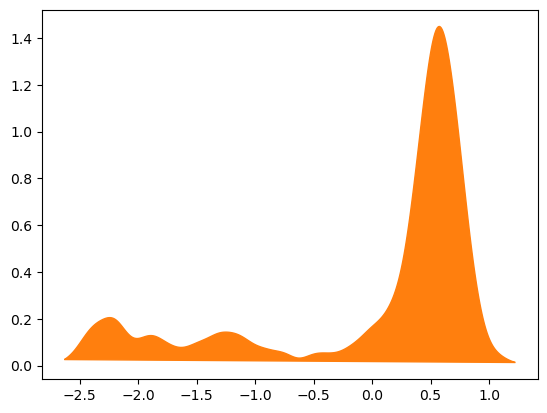

(array([  2.,   7.,  10.,  15.,  16.,  21.,   9.,   7.,   9.,  14.,   7.,
          7.,   6.,   5.,   8.,   8.,  11.,  12.,   8.,  13.,   8.,   4.,
          7.,   4.,   7.,   0.,   2.,   4.,   5.,   4.,   3.,   7.,   8.,
         11.,  16.,  14.,  19.,  26.,  53.,  78., 110., 128., 103.,  89.,
         48.,  30.,   8.,   4.,   3.,   2.]),
 array([-2.63095308, -2.55385714, -2.4767612 , -2.39966527, -2.32256933,
        -2.24547339, -2.16837746, -2.09128152, -2.01418558, -1.93708964,
        -1.85999371, -1.78289777, -1.70580183, -1.6287059 , -1.55160996,
        -1.47451402, -1.39741808, -1.32032215, -1.24322621, -1.16613027,
        -1.08903434, -1.0119384 , -0.93484246, -0.85774653, -0.78065059,
        -0.70355465, -0.62645871, -0.54936278, -0.47226684, -0.3951709 ,
        -0.31807497, -0.24097903, -0.16388309, -0.08678715, -0.00969122,
         0.06740472,  0.14450066,  0.22159659,  0.29869253,  0.37578847,
         0.4528844 ,  0.52998034,  0.60707628,  0.68417222,  0.76126815,
 

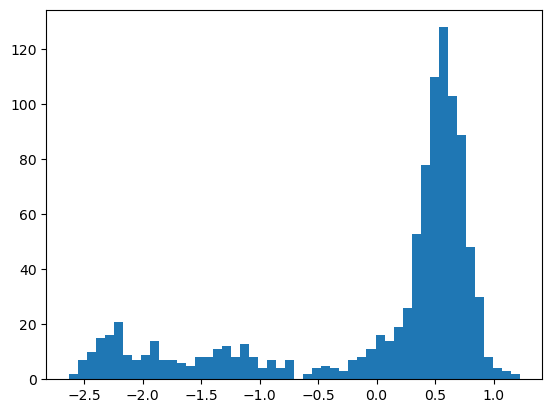

In [ ]:
# Exemplary KDE plot:
id = 5
x = datasets[id].cause.flatten().numpy().reshape((-1,1))

bandwidths = np.logspace(-2, 1, 50)  # e.g. from 0.01 to 10

grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': bandwidths},
                    cv=5)

grid.fit(x)

kde = grid.best_estimator_
x_test = np.linspace(x.min(), x.max(), 500).reshape((-1,1))
log_dens = kde.score_samples(x_test)

plt.fill(x_test, np.exp(log_dens), c='tab:orange')
plt.show()
plt.hist(x, bins=50)